# Самостоятельное задание №1
## Применение CNN для классификации подлинных и поддельных изображений

В этом ноутбуке собран отчёт по теме применения свёрточной нейронной сети для задачи бинарной классификации изображений: "подлинное" против "поддельное".

Акценты отчёта:
- обоснование выбора архитектуры CNN;
- демонстрация transfer learning и fine-tuning;
- оценка качества на метриках и матрице ошибок;
- интерпретация ошибок и визуализация Grad-CAM.

## 1. Постановка задачи

Цель работы - построить модель, которая по изображению определяет, является ли оно подлинным или содержит признаки подделки, монтажа или фальсификации. Для таких задач важно не только распознать крупные формы, но и уловить мелкие текстурные артефакты, следы сжатия, неоднородности печати и аномалии в локальных областях изображения.

Для этого разумно использовать предобученную CNN с transfer learning, а затем выполнить тонкую настройку части верхних слоёв под специфику датасета.

In [1]:
!pip -q install kagglehub

import copy
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, models, transforms

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
# Датасет скачивается в Colab через kagglehub
DATASET_ROOT = Path(kagglehub.dataset_download('robinreni/signature-verification-dataset'))
print('Path to dataset files:', DATASET_ROOT)

100%|██████████| 601M/601M [00:16<00:00, 38.9MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/robinreni/signature-verification-dataset/versions/2


In [3]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_EPOCHS_STAGE1 = 5
NUM_EPOCHS_STAGE2 = 3

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('IMAGE_SIZE =', IMAGE_SIZE)
print('BATCH_SIZE =', BATCH_SIZE)
print('NUM_WORKERS =', NUM_WORKERS)
print('NUM_EPOCHS_STAGE1 =', NUM_EPOCHS_STAGE1)
print('NUM_EPOCHS_STAGE2 =', NUM_EPOCHS_STAGE2)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_EPOCHS_STAGE1 = 5
NUM_EPOCHS_STAGE2 = 3


## 2. Обзор данных

В работе используется датасет подписей **Signature Verification Dataset** (Kaggle, `robinreni/signature-verification-dataset`). Он содержит изображения **подлинных** и **поддельных/сфальсифицированных** подписей.

Ниже выполняются шаги, требуемые в отчёте:
- загрузка и разбиение на `train/val/test` (если `val` отсутствует — деление `train` на `train/val`);
- вывод объёма выборок и примеров изображений;
- расчёт **баланса классов** (доли `real`/`fake`), чтобы понимать возможный перекос данных.

Ожидаемая структура (совместима с `ImageFolder`):

```text
data/
- train/
  - real/
  - fake/
- val/
  - real/
  - fake/
- test/
  - real/
  - fake/
```

### 2.1 Предобработка и аугментация

Аугментации применяются **только** к обучающей выборке, чтобы снизить переобучение и сделать модель устойчивее к поворотам, кадрированию и изменениям условий съёмки/сканирования. Это важно для задач детекции подделок, потому что признаки фальсификации могут проявляться по-разному в зависимости от ракурса, качества печати и уровня сжатия.

- `train_transform`: случайное кадрирование, отражение, поворот, изменение яркости/контраста (обучаем инвариантности).
- `eval_transform`: только приведение к размеру и нормализация (честная оценка без искажений).

In [4]:
def to_binary_label(dataset, label):
    class_name = dataset.classes[label].lower()
    return 1 if ('forg' in class_name or 'fake' in class_name or 'forged' in class_name) else 0


class TransformedSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform
        self.classes = ['real', 'fake']

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, label = self.dataset[self.indices[index]]
        image = self.transform(image)
        return image, to_binary_label(self.dataset, label)


class BinaryImageFolder(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
        self.classes = ['real', 'fake']

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, label = self.dataset[index]
        image = self.transform(image)
        return image, to_binary_label(self.dataset, label)


def find_split_dir(root: Path, candidates, required=True):
    candidate_names = {name.lower() for name in candidates}
    search_roots = [root] + [path for path in root.rglob('*') if path.is_dir()]

    for path in search_roots:
        if path.name.lower() in candidate_names:
            return path

    if required:
        raise FileNotFoundError(f'Не найдена папка из списка: {candidates} внутри {root}')
    return None


def build_datasets(train_dir: Path, val_dir: Path | None, test_dir: Path):
    base_train_dataset = datasets.ImageFolder(root=str(train_dir), transform=None)
    base_test_dataset = datasets.ImageFolder(root=str(test_dir), transform=None)

    if val_dir is not None and val_dir.exists():
        train_dataset = BinaryImageFolder(datasets.ImageFolder(root=str(train_dir), transform=None), train_transform)
        val_dataset = BinaryImageFolder(datasets.ImageFolder(root=str(val_dir), transform=None), eval_transform)
    else:
        val_size = max(1, int(0.2 * len(base_train_dataset)))
        train_size = len(base_train_dataset) - val_size
        permutation = torch.randperm(len(base_train_dataset), generator=torch.Generator().manual_seed(42)).tolist()
        train_indices = permutation[:train_size]
        val_indices = permutation[train_size:]
        train_dataset = TransformedSubset(base_train_dataset, train_indices, train_transform)
        val_dataset = TransformedSubset(base_train_dataset, val_indices, eval_transform)

    test_dataset = BinaryImageFolder(base_test_dataset, eval_transform)
    return train_dataset, val_dataset, test_dataset


TRAIN_DIR = find_split_dir(DATASET_ROOT, ['train', 'Train', 'training', 'Training'])
VAL_DIR = find_split_dir(DATASET_ROOT, ['val', 'Val', 'valid', 'Valid', 'validation', 'Validation'], required=False)
TEST_DIR = find_split_dir(DATASET_ROOT, ['test', 'Test', 'testing', 'Testing'])

print('Train dir:', TRAIN_DIR)
print('Val dir:', VAL_DIR)
print('Test dir:', TEST_DIR)

if TRAIN_DIR.exists() and TEST_DIR.exists():
    train_dataset, val_dataset, test_dataset = build_datasets(TRAIN_DIR, VAL_DIR if VAL_DIR is not None and VAL_DIR.exists() else None, TEST_DIR)
    class_names = ['real', 'fake']
    print('Classes:', class_names)
    print('Train size:', len(train_dataset))
    print('Val size:', len(val_dataset))
    print('Test size:', len(test_dataset))
else:
    train_dataset = val_dataset = test_dataset = None
    class_names = ['real', 'fake']
    print('Датасет не найден. Укажите корректные пути в DATASET_ROOT.')

Train dir: /root/.cache/kagglehub/datasets/robinreni/signature-verification-dataset/versions/2/sign_data/train
Val dir: None
Test dir: /root/.cache/kagglehub/datasets/robinreni/signature-verification-dataset/versions/2/sign_data/test
Classes: ['real', 'fake']
Train size: 1320
Val size: 329
Test size: 500


In [5]:
# Баланс классов (0=real, 1=fake) — важен для интерпретации метрик

def _binary_counts(dataset):
    counts = {0: 0, 1: 0}

    if isinstance(dataset, TransformedSubset):
        base = dataset.dataset
        for idx in dataset.indices:
            original_label = base.targets[idx]
            counts[to_binary_label(base, original_label)] += 1
        return counts

    if isinstance(dataset, BinaryImageFolder):
        base = dataset.dataset
        for original_label in base.targets:
            counts[to_binary_label(base, original_label)] += 1
        return counts

    # fallback (может быть медленнее, т.к. читает изображения)
    for _, y in dataset:
        counts[int(y)] += 1
    return counts


def print_class_balance(name: str, dataset):
    if dataset is None:
        print(f"{name}: dataset отсутствует")
        return

    counts = _binary_counts(dataset)
    total = counts[0] + counts[1]
    if total == 0:
        print(f"{name}: пустая выборка")
        return

    print(
        f"{name}: total={total} | "
        f"real={counts[0]} ({counts[0] / total:.1%}) | "
        f"fake={counts[1]} ({counts[1] / total:.1%})"
    )


if train_dataset is not None:
    print_class_balance("train", train_dataset)
    print_class_balance("val", val_dataset)
    print_class_balance("test", test_dataset)
else:
    print("Датасет не найден — баланс классов не рассчитан.")

train: total=1320 | real=703 (53.3%) | fake=617 (46.7%)
val: total=329 | real=184 (55.9%) | fake=145 (44.1%)
test: total=500 | real=252 (50.4%) | fake=248 (49.6%)


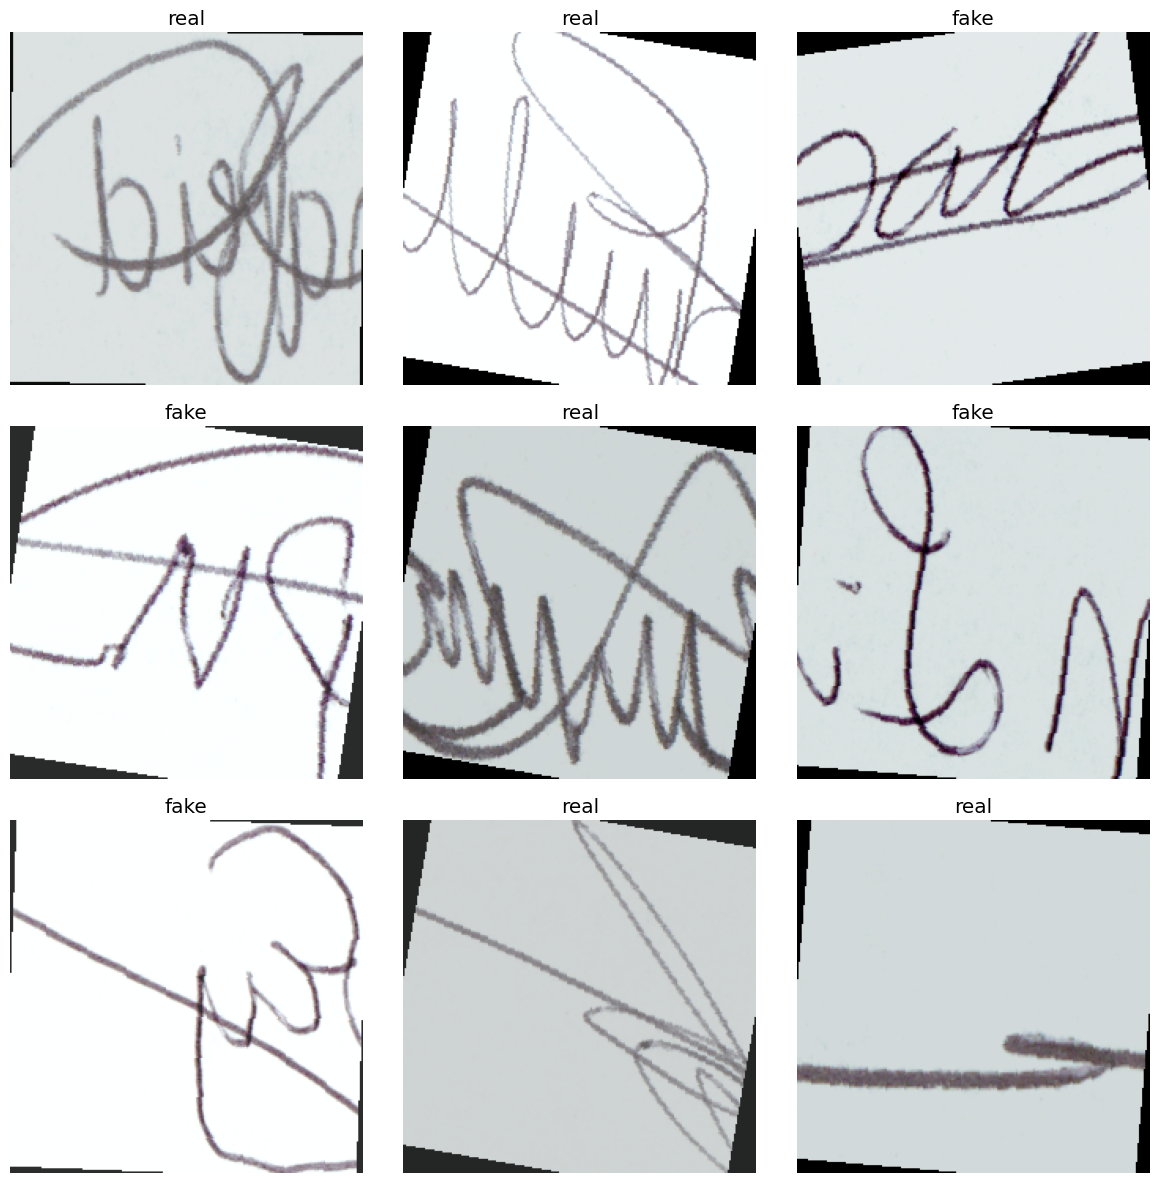

In [6]:
def denormalize(image_tensor: torch.Tensor) -> np.ndarray:
    image = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(image, 0, 1)

def show_batch(dataset, n=9):
    if dataset is None:
        return
    indices = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    rows = int(np.ceil(len(indices) / 3))
    plt.figure(figsize=(12, 4 * rows))
    for i, idx in enumerate(indices, start=1):
        image, label = dataset[idx]
        plt.subplot(rows, 3, i)
        plt.imshow(denormalize(image))
        plt.title(class_names[label])
        plt.axis('off')
    plt.tight_layout()

show_batch(train_dataset)

In [7]:
def make_loader(dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

if train_dataset is not None:
    train_loader = make_loader(train_dataset, shuffle=True)
    val_loader = make_loader(val_dataset, shuffle=False)
    test_loader = make_loader(test_dataset, shuffle=False)
    print('Batches per epoch:', len(train_loader))
else:
    train_loader = val_loader = test_loader = None

Batches per epoch: 42


## 3. Обоснование выбора архитектуры

В качестве базовой модели выбрана ResNet50. Причины выбора:
- остаточные связи позволяют глубокой сети устойчиво обучаться без деградации градиента;
- предобучение на ImageNet даёт полезные низкоуровневые и среднеуровневые признаки, которые хорошо переносятся на задачу анализа текстур и локальных артефактов;
- архитектура достаточно выразительна для извлечения мелких различий между подлинными и поддельными изображениями;
- ResNet50 обычно даёт хороший баланс между качеством и вычислительной стоимостью, особенно в режиме transfer learning.

На практике бинарная классификация подделок часто выигрывает от глубокой, но предобученной модели: она уже умеет выделять края, структуры и текстуры, а задача дообучения сводится к адаптации признаков к специфике домена.

In [8]:
def build_model(num_classes: int = 1, freeze_backbone: bool = True):
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)

    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )
    return model

model = build_model().to(device)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 168MB/s] 


Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=1, bias=True)
)


In [9]:
def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print('Trainable parameters:', count_trainable_parameters(model))

with torch.no_grad():
    dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    print('Logits shape:', model(dummy).shape)

Trainable parameters: 524801
Logits shape: torch.Size([2, 1])


## 4. Двухэтапное обучение (Transfer Learning + Fine-tuning)

**Предобученная база:** `ResNet50_Weights.DEFAULT` (ImageNet). В ResNet уже встроен `Global Average Pooling` перед полносвязным слоем, поэтому для адаптации под задачу достаточно заменить `fc` на свою «голову».

**Голова модели (классификатор):** `Linear → ReLU → Dropout → Linear(1)`.
- На выходе получаем **логит** (одно число).
- Вероятность класса `fake` вычисляется как `sigmoid(logit)`.

**Функция потерь:** `BCEWithLogitsLoss` — стандартный и численно устойчивый вариант для бинарной классификации по логитам.

**Оптимизатор:** `AdamW` только для обучаемых параметров (тех, где `requires_grad=True`).

**Два этапа обучения:**
- **Этап 1 (transfer learning):** заморозка бэкбоуна ResNet50 и обучение только головы (быстрее, меньше риск переобучения).
- **Этап 2 (fine-tuning):** разморозка верхнего блока `layer4` + обучение с маленьким learning rate для доменной адаптации признаков.

Метрики для отчёта: accuracy, precision, recall, F1-score и confusion matrix (в задачах безопасности особенно важен recall для класса `fake`, т.к. пропуск подделки обычно дороже ложной тревоги).

In [10]:
criterion = nn.BCEWithLogitsLoss()

def move_batch_to_device(batch):
    images, targets = batch
    images = images.to(device, non_blocking=True)
    targets = targets.float().unsqueeze(1).to(device, non_blocking=True)
    return images, targets

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    all_probs = []
    all_targets = []

    for batch in loader:
        images, targets = move_batch_to_device(batch)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, targets)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_probs.append(torch.sigmoid(logits).detach().cpu())
        all_targets.append(targets.detach().cpu())

    probs = torch.cat(all_probs).squeeze(1).numpy()
    targets = torch.cat(all_targets).squeeze(1).numpy().astype(int)
    preds = (probs >= 0.5).astype(int)
    avg_loss = total_loss / len(loader.dataset)
    accuracy = (preds == targets).mean()
    return avg_loss, accuracy, preds, targets, probs

def fit_model(model, train_loader, val_loader, epochs, lr, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    history = {key: [] for key in ['train_loss', 'train_acc', 'val_loss', 'val_acc']}
    best_state = None
    best_val_acc = -1.0

    for epoch in range(epochs):
        train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, optimizer)
        with torch.no_grad():
            val_loss, val_acc, _, _, _ = run_epoch(model, val_loader, optimizer=None)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch + 1}/{epochs} | train loss={train_loss:.4f} acc={train_acc:.4f} | val loss={val_loss:.4f} acc={val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='train')
    axes[0].plot(epochs, history['val_loss'], label='val')
    axes[0].set_title(f'{title} | Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs, history['train_acc'], label='train')
    axes[1].plot(epochs, history['val_acc'], label='val')
    axes[1].set_title(f'{title} | Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()

Epoch 1/5 | train loss=0.4576 acc=0.8189 | val loss=0.4110 acc=0.7994
Epoch 2/5 | train loss=0.2929 acc=0.8826 | val loss=0.3017 acc=0.8875
Epoch 3/5 | train loss=0.2408 acc=0.9121 | val loss=0.3117 acc=0.8571
Epoch 4/5 | train loss=0.2437 acc=0.9015 | val loss=0.2468 acc=0.9058
Epoch 5/5 | train loss=0.2142 acc=0.9220 | val loss=0.3395 acc=0.8602


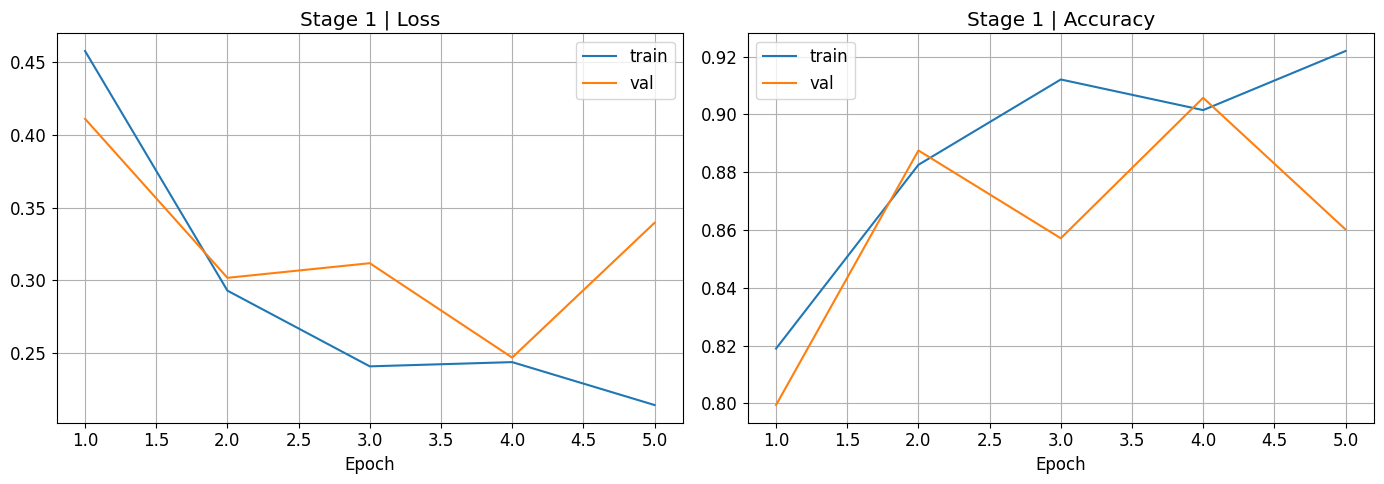

In [11]:
history_stage1 = None

if train_loader is not None:
    model_stage1 = build_model(freeze_backbone=True).to(device)
    model_stage1, history_stage1 = fit_model(
        model_stage1,
        train_loader,
        val_loader,
        epochs=NUM_EPOCHS_STAGE1,
        lr=1e-3,
    )
    plot_history(history_stage1, 'Stage 1')
else:
    model_stage1 = model
    print('Пропуск обучения: датасет не найден.')

Epoch 1/3 | train loss=0.1920 acc=0.9265 | val loss=0.2362 acc=0.9119
Epoch 2/3 | train loss=0.2159 acc=0.9114 | val loss=0.2120 acc=0.9271
Epoch 3/3 | train loss=0.1931 acc=0.9189 | val loss=0.2110 acc=0.9210


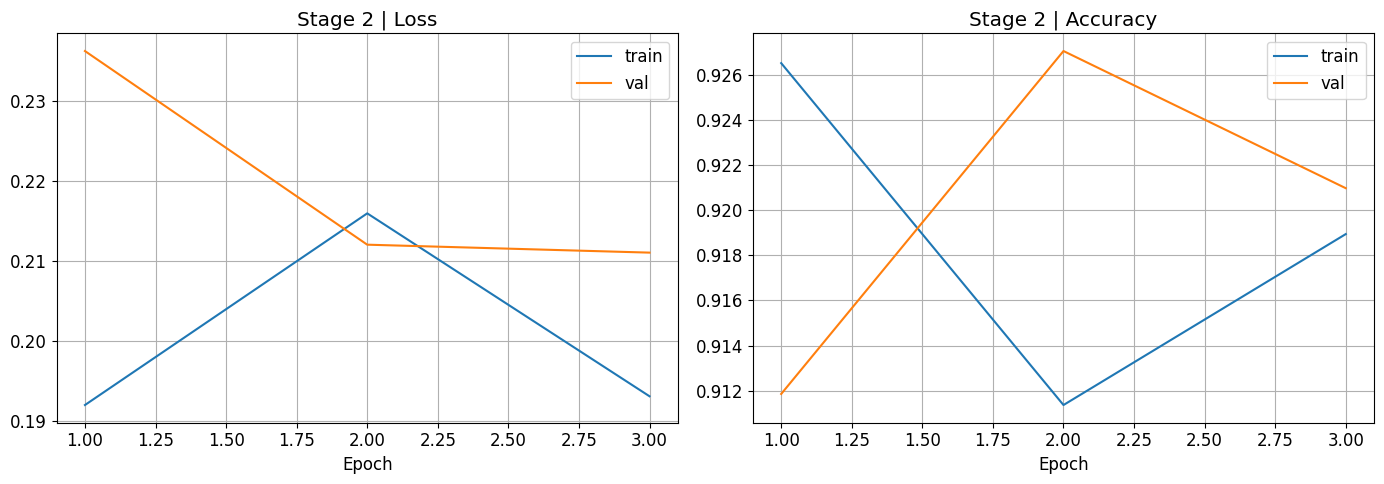

In [12]:
def unfreeze_top_layers(model: nn.Module, n_blocks: int = 1):
    for parameter in model.parameters():
        parameter.requires_grad = False

    for parameter in model.fc.parameters():
        parameter.requires_grad = True

    for parameter in model.layer4.parameters():
        parameter.requires_grad = True

    if n_blocks >= 2:
        for parameter in model.layer3.parameters():
            parameter.requires_grad = True

    return model

history_stage2 = None

if train_loader is not None:
    model_stage2 = copy.deepcopy(model_stage1)
    model_stage2 = unfreeze_top_layers(model_stage2, n_blocks=1).to(device)
    model_stage2, history_stage2 = fit_model(
        model_stage2,
        train_loader,
        val_loader,
        epochs=NUM_EPOCHS_STAGE2,
        lr=1e-5,
        weight_decay=1e-4,
    )
    plot_history(history_stage2, 'Stage 2')
else:
    model_stage2 = model_stage1

## 5. Оценка качества

Для интерпретации результатов используем accuracy, precision, recall, F1-score и confusion matrix. Для задач безопасности часто особенно важен recall класса "поддельный", потому что пропуск подделки обычно опаснее ложного срабатывания.

{'loss': 0.21208117198944093, 'accuracy': np.float64(0.914), 'precision': 0.9253112033195021, 'recall': 0.8991935483870968, 'f1': 0.9120654396728016}
              precision    recall  f1-score   support

        real       0.90      0.93      0.92       252
        fake       0.93      0.90      0.91       248

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



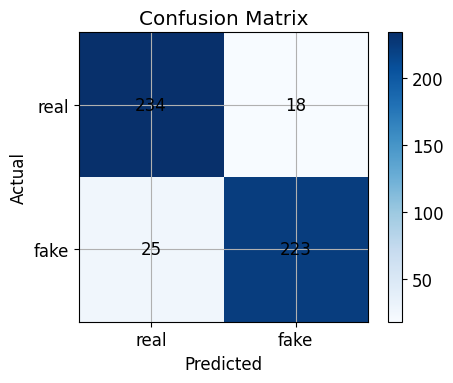

In [13]:
def evaluate(model, loader):
    model.eval()
    all_probs = []
    all_targets = []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            images, targets = move_batch_to_device(batch)
            logits = model(images)
            loss = criterion(logits, targets)
            total_loss += loss.item() * images.size(0)
            all_probs.append(torch.sigmoid(logits).cpu())
            all_targets.append(targets.cpu())

    probs = torch.cat(all_probs).squeeze(1).numpy()
    targets = torch.cat(all_targets).squeeze(1).numpy().astype(int)
    preds = (probs >= 0.5).astype(int)
    metrics = {
        'loss': total_loss / len(loader.dataset),
        'accuracy': (preds == targets).mean(),
        'precision': precision_score(targets, preds, zero_division=0),
        'recall': recall_score(targets, preds, zero_division=0),
        'f1': f1_score(targets, preds, zero_division=0),
    }
    return metrics, targets, preds, probs

def plot_confusion_matrix(targets, preds, labels):
    matrix = confusion_matrix(targets, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix')
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, matrix[i, j], ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax)
    plt.tight_layout()

if test_loader is not None:
    metrics, targets, preds, probs = evaluate(model_stage2, test_loader)
    print(metrics)
    print(classification_report(targets, preds, target_names=class_names, zero_division=0))
    plot_confusion_matrix(targets, preds, class_names)
else:
    metrics = targets = preds = probs = None
    print('Датасет не найден, оценка не выполнена.')

In [14]:
# Таблица итоговых метрик (как в рекомендуемой структуре отчёта)
from IPython.display import Markdown, display

if metrics is not None:
    display(Markdown("### Итоговые метрики на тестовой выборке"))

    display(
        Markdown(
            "| Метрика | Значение |\n"
            "|---|---:|\n"
            f"| Loss | {metrics['loss']:.4f} |\n"
            f"| Accuracy | {metrics['accuracy']:.3f} |\n"
            f"| Precision (fake) | {metrics['precision']:.3f} |\n"
            f"| Recall (fake) | {metrics['recall']:.3f} |\n"
            f"| F1 (fake) | {metrics['f1']:.3f} |\n"
        )
    )

    cm = confusion_matrix(targets, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    display(
        Markdown(
            "**Разбор ошибок (положительный класс = `fake`)**\n\n"
            f"- TP (верно найдено подделок): {tp}\n"
            f"- FN (пропущено подделок): {fn}\n"
            f"- FP (ложные тревоги): {fp}\n"
            f"- TN (верно найдено подлинных): {tn}"
        )
    )

    if metrics['recall'] < metrics['precision']:
        display(
            Markdown(
                "**Интерпретация:** recall для `fake` ниже precision — модель чаще **пропускает** часть подделок (FN). "
                "Если важно минимизировать пропуск подделок, можно подбирать порог решения и/или усиливать данные."
            )
        )
    else:
        display(
            Markdown(
                "**Интерпретация:** precision ниже recall — модель чаще даёт **ложные тревоги** (FP). "
                "Для снижения FP можно подбирать порог решения и/или улучшать качество данных (фон/шум/контраст)."
            )
        )
else:
    print('Метрики отсутствуют — сначала выполните блок оценки качества.')

### Итоговые метрики на тестовой выборке

| Метрика | Значение |
|---|---:|
| Loss | 0.2121 |
| Accuracy | 0.914 |
| Precision (fake) | 0.925 |
| Recall (fake) | 0.899 |
| F1 (fake) | 0.912 |


**Разбор ошибок (положительный класс = `fake`)**

- TP (верно найдено подделок): 223
- FN (пропущено подделок): 25
- FP (ложные тревоги): 18
- TN (верно найдено подлинных): 234

**Интерпретация:** recall для `fake` ниже precision — модель чаще **пропускает** часть подделок (FN). Если важно минимизировать пропуск подделок, можно подбирать порог решения и/или усиливать данные.

## 6. Интерпретация ошибок

После обучения полезно изучить ошибки модели. Если поддельное изображение имеет высокое качество печати, мало артефактов или выглядит почти как оригинал, модель может ошибочно отнести его к классу "подлинное". Наоборот, дефекты освещения, сильное сжатие или нестандартный фон могут провоцировать ложные тревоги.

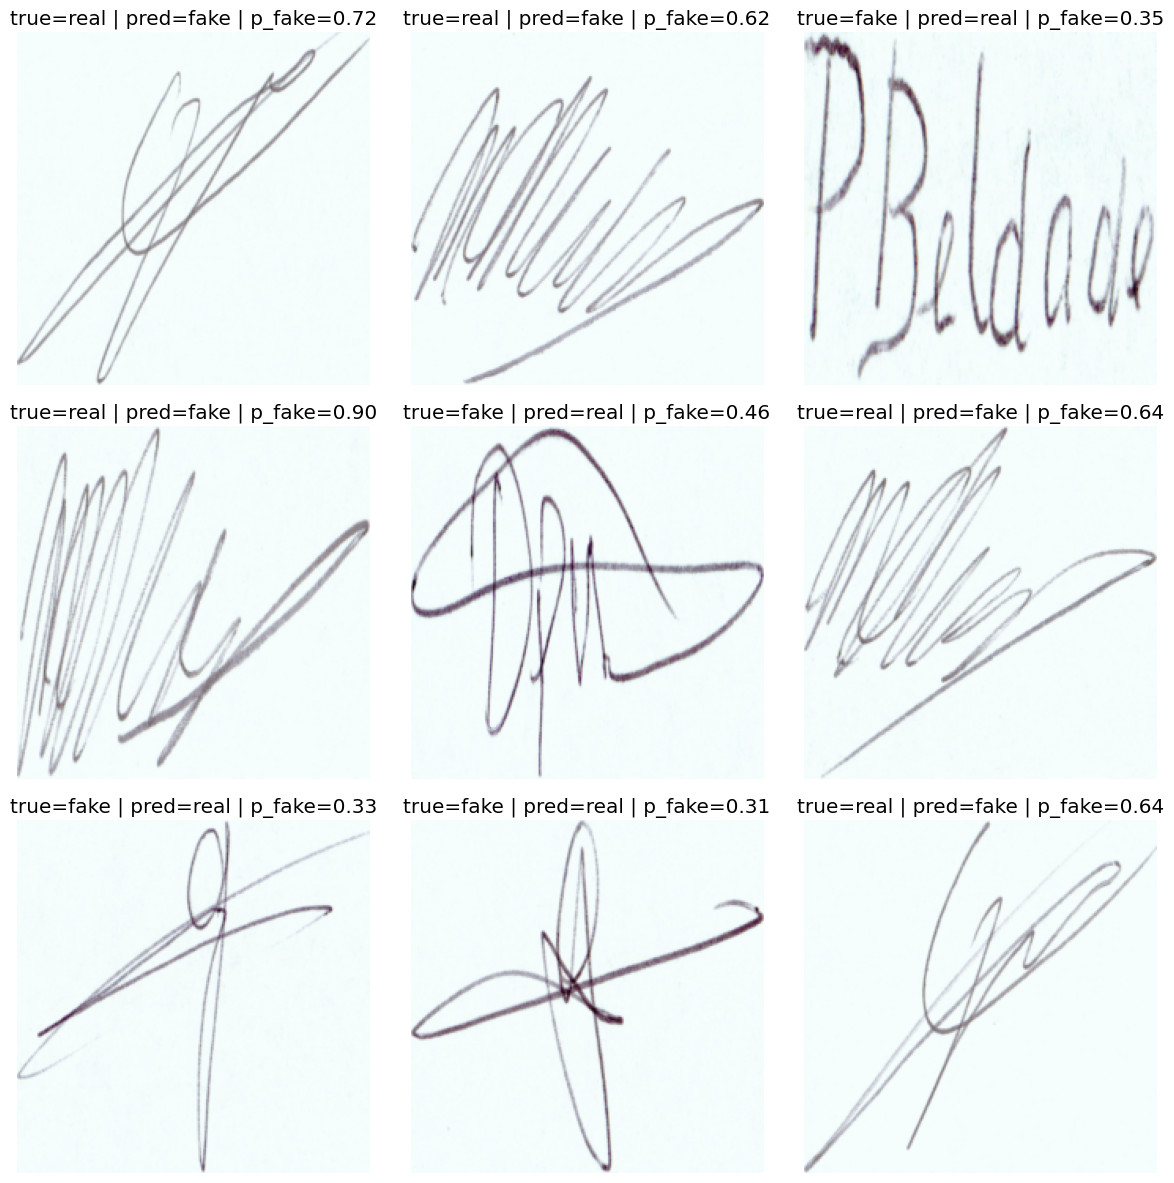

In [15]:
def show_misclassified(dataset, preds, targets, probs=None, max_items=9, seed=42):
    if dataset is None or preds is None or targets is None:
        return

    errors = np.where(preds != targets)[0]
    if len(errors) == 0:
        print('Ошибок на выбранной выборке не найдено.')
        return

    n = min(max_items, len(errors))
    rng = np.random.default_rng(seed)
    selected = rng.choice(errors, size=n, replace=False) if len(errors) > n else errors

    plt.figure(figsize=(12, 4 * int(np.ceil(n / 3))))
    for i, idx in enumerate(selected, start=1):
        image, label = dataset[int(idx)]
        plt.subplot(int(np.ceil(n / 3)), 3, i)
        plt.imshow(denormalize(image))

        title = f'true={class_names[label]} | pred={class_names[preds[idx]]}'
        if probs is not None:
            title += f' | p_fake={probs[idx]:.2f}'

        plt.title(title)
        plt.axis('off')

    plt.tight_layout()


if test_loader is not None:
    show_misclassified(test_dataset, preds, targets, probs=probs)

## 7. Grad-CAM

Grad-CAM показывает, какие области изображения сильнее всего повлияли на решение модели. Для задачи поиска подделок это полезно, потому что можно проверить, опирается ли сеть на релевантные локальные артефакты, а не на случайный фон или посторонние признаки.

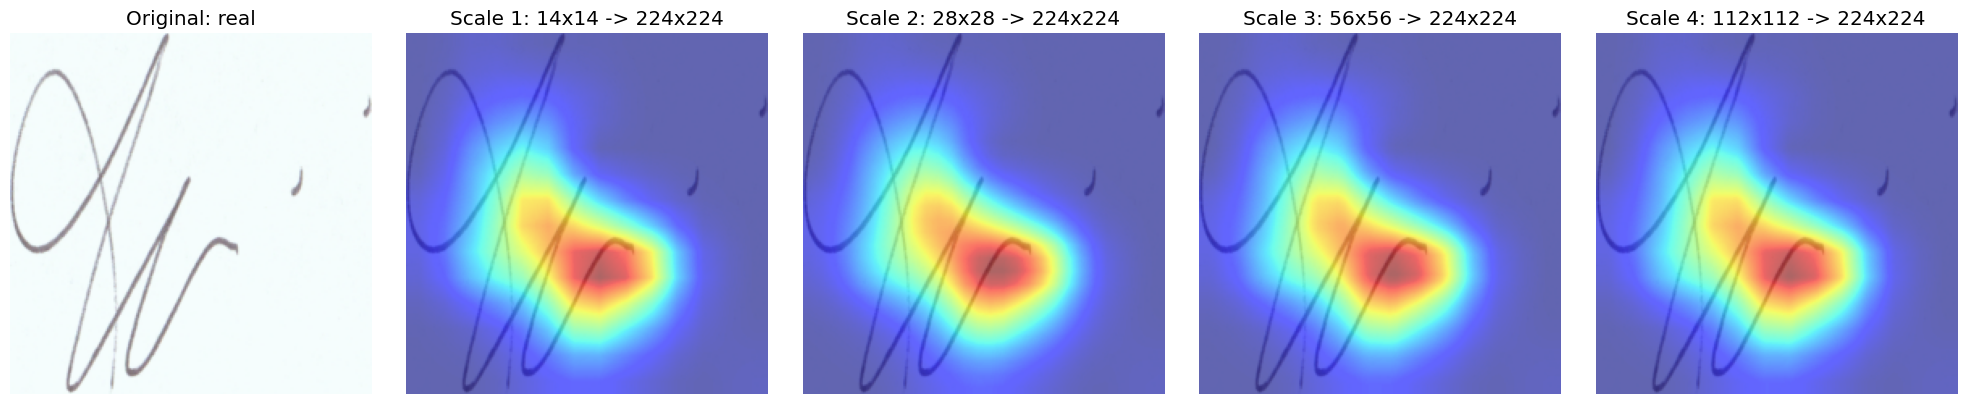

In [18]:
def get_last_conv_layer(model: nn.Module):
    return model.layer4[-1]

import torch.nn.functional as F

def make_gradcam_heatmap(
    model: nn.Module,
    image_tensor: torch.Tensor,
    target_class: int | None = None,
    upsample_steps: int = 4,
    base_size: int = 14,
    ):
    """
    Вычисляет Grad-CAM и возвращает список (scale, heatmap_full) для многошагового увеличения.

    scale — промежуточное разрешение CAM перед приведением к размеру изображения.
    """
    model.eval()
    activations = {}
    gradients = {}
    target_layer = get_last_conv_layer(model)

    def forward_hook(module, inputs, output):
        activations['value'] = output.detach()

    def backward_hook(module, grad_input, grad_output):
        gradients['value'] = grad_output[0].detach()

    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad_(True)
    logits = model(image_tensor)
    if target_class is None:
        target_class = int((torch.sigmoid(logits) >= 0.5).item())

    # Для бинарной модели один логит соответствует классу "fake".
    # Чтобы получить Grad-CAM для класса "real", используем -logit (т.к. p(real)=sigmoid(-logit)).
    score = logits[:, 0] if target_class == 1 else -logits[:, 0]
    model.zero_grad(set_to_none=True)
    score.backward()

    forward_handle.remove()
    backward_handle.remove()

    acts = activations['value'][0]
    grads = gradients['value'][0]
    weights = grads.mean(dim=(1, 2), keepdim=True)
    cam = torch.relu((weights * acts).sum(dim=0))

    # Нормировка
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # размеры изображения
    _, _, H, W = image_tensor.shape
    heatmaps = []
    base_cam = cam.unsqueeze(0).unsqueeze(0)
    base_cam = F.interpolate(base_cam, size=(base_size, base_size), mode='bilinear', align_corners=False)[0, 0]

    for step in range(1, upsample_steps + 1):
        scale = int(base_size * (2 ** (step - 1)))
        scale = min(scale, H, W)
        out = F.interpolate(
            base_cam.unsqueeze(0).unsqueeze(0),
            size=(scale, scale),
            mode='bilinear',
            align_corners=False,
        )[0, 0]
        out_full = F.interpolate(
            out.unsqueeze(0).unsqueeze(0),
            size=(H, W),
            mode='bilinear',
            align_corners=False,
        )[0, 0]
        out_full = out_full - out_full.min()
        out_full = out_full / (out_full.max() + 1e-8)
        heatmaps.append((scale, out_full.cpu().numpy()))

    return heatmaps

def show_gradcam_multiscale(model, dataset, index=0, upsample_steps: int = 4, base_size: int = 14):
    if dataset is None:
        return
    image, label = dataset[index]
    heatmaps = make_gradcam_heatmap(model, image, upsample_steps=upsample_steps, base_size=base_size)
    original = denormalize(image)

    n = len(heatmaps) + 1
    plt.figure(figsize=(4 * n, 4))

    plt.subplot(1, n, 1)
    plt.imshow(original)
    plt.title(f'Original: {class_names[label]}')
    plt.axis('off')

    for i, (scale, hm) in enumerate(heatmaps, start=2):
        plt.subplot(1, n, i)
        plt.imshow(original)
        plt.imshow(hm, cmap='jet', alpha=0.6)
        plt.title(f'Scale {i-1}: {scale}x{scale} -> {hm.shape[0]}x{hm.shape[1]}')
        plt.axis('off')
    plt.tight_layout()


if test_loader is not None and len(test_dataset) > 0:
    show_gradcam_multiscale(model_stage2, test_dataset, index=0, upsample_steps=4, base_size=14)

## Дополнительно (не обязательно по ТЗ)

Следующий блок — расширенные диагностические графики (ROC/PR, калибровка, гистограмма вероятностей, нормализованная матрица ошибок, batch Grad‑CAM, t‑SNE). Для **минимального** отчёта они не требуются, поэтому запуск сделан опциональным через флаг `RUN_EXTRA`.

In [17]:
# Дополнительные визуализации (опционально)
# ROC/PR, calibration, prob-hist, нормализованная матрица ошибок,
# фильтры по уверенности, batch Grad-CAM и t-SNE встраивание признаков

RUN_EXTRA = False  # поставьте True, если хотите построить доп.графики

if RUN_EXTRA and test_loader is not None and probs is not None and targets is not None:
    try:
        import seaborn as sns
    except ImportError as exc:
        raise ImportError("Для доп.визуализаций установите seaborn: `pip install seaborn`") from exc

    from sklearn.calibration import calibration_curve
    from sklearn.manifold import TSNE
    from sklearn.metrics import (
        auc,
        average_precision_score,
        precision_recall_curve,
        roc_curve,
    )

    def plot_roc_pr(probs, targets):
        fpr, tpr, _ = roc_curve(targets, probs)
        roc_auc = auc(fpr, tpr)
        precision, recall, _ = precision_recall_curve(targets, probs)
        ap = average_precision_score(targets, probs)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
        axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
        axes[0].set_title('ROC Curve')
        axes[0].set_xlabel('FPR')
        axes[0].set_ylabel('TPR')
        axes[0].legend()

        axes[1].plot(recall, precision, label=f'AP = {ap:.3f}')
        axes[1].set_title('Precision-Recall')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].legend()
        plt.tight_layout()

    def plot_calibration(probs, targets, n_bins=10):
        prob_true, prob_pred = calibration_curve(targets, probs, n_bins=n_bins)
        plt.figure(figsize=(6, 5))
        plt.plot(prob_pred, prob_true, 's-', label='Calibration')
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
        plt.xlabel('Predicted probability')
        plt.ylabel('Observed frequency')
        plt.title('Calibration curve')
        plt.legend()
        plt.tight_layout()

    def plot_prob_hist(probs, targets, bins=20):
        plt.figure(figsize=(8, 4))
        sns.histplot(
            probs[targets == 0],
            color='C0',
            label='real',
            bins=bins,
            kde=False,
            stat='density',
            alpha=0.6,
        )
        sns.histplot(
            probs[targets == 1],
            color='C1',
            label='fake',
            bins=bins,
            kde=False,
            stat='density',
            alpha=0.6,
        )
        plt.xlabel('Predicted probability (fake)')
        plt.legend()
        plt.title('Probability histogram by class')
        plt.tight_layout()

    def plot_normalized_confusion(targets, preds, labels):
        mat = confusion_matrix(targets, preds, labels=[0, 1])
        mat_norm = mat.astype('float') / mat.sum(axis=1, keepdims=True)
        plt.figure(figsize=(5, 4))
        sns.heatmap(mat_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Normalized Confusion Matrix')
        plt.tight_layout()

    def show_by_confidence(dataset, probs, preds, targets, low=None, high=None, n=9):
        idxs = np.arange(len(probs))
        if low is not None:
            idxs = idxs[probs >= low]
        if high is not None:
            idxs = idxs[probs <= high]
        idxs = idxs.tolist()

        if len(idxs) == 0:
            print('Нет примеров в заданном диапазоне')
            return

        sel = idxs[:n]
        plt.figure(figsize=(12, 4 * int(np.ceil(len(sel) / 3))))
        for i, idx in enumerate(sel, start=1):
            img, label = dataset[idx]
            plt.subplot(int(np.ceil(len(sel) / 3)), 3, i)
            plt.imshow(denormalize(img))
            plt.title(f'true={class_names[label]} | pred={class_names[preds[idx]]} | p={probs[idx]:.2f}')
            plt.axis('off')
        plt.tight_layout()

    def batch_show_gradcam(model, dataset, indices, upsample_steps=4, base_size=14):
        k = len(indices)
        cols = min(3, k)
        rows = int(np.ceil(k / cols))
        plt.figure(figsize=(4 * cols, 4 * rows))
        for i, idx in enumerate(indices, start=1):
            img, label = dataset[idx]
            hmaps = make_gradcam_heatmap(model, img, upsample_steps=upsample_steps, base_size=base_size)
            overlay = denormalize(img)
            final_hm = hmaps[-1]
            plt.subplot(rows, cols, i)
            plt.imshow(overlay)
            plt.imshow(final_hm, cmap='jet', alpha=0.5)
            plt.title(f'idx={idx} true={class_names[label]}')
            plt.axis('off')
        plt.tight_layout()

    def extract_features(model, loader, max_samples=1000):
        model.eval()
        backbone = torch.nn.Sequential(*list(model.children())[:-1]).to(device)
        features = []
        labels = []
        count = 0

        with torch.no_grad():
            for batch in loader:
                images, batch_targets = move_batch_to_device(batch)
                feats = backbone(images)  # [B, C, 1, 1]
                feats = feats.view(feats.size(0), -1).cpu().numpy()
                features.append(feats)
                labels.append(batch_targets.cpu().numpy().astype(int))
                count += feats.shape[0]
                if count >= max_samples:
                    break

        features = np.vstack(features)[:max_samples]
        labels = np.concatenate(labels)[:max_samples]
        return features, labels

    def plot_tsne(model, loader, max_samples=500, perplexity=30):
        feats, labs = extract_features(model, loader, max_samples=max_samples)
        ts = TSNE(n_components=2, perplexity=perplexity, random_state=42)
        emb = ts.fit_transform(feats)
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=labs, palette=['C0', 'C1'], alpha=0.7)
        plt.title('t-SNE of extracted features')
        plt.legend(title='class')
        plt.tight_layout()

    print('Построение ROC/PR, calibration и histogram...')
    plot_roc_pr(probs, targets)
    plot_calibration(probs, targets)
    plot_prob_hist(probs, targets)
    plot_normalized_confusion(targets, preds, class_names)

    print('Покажем несколько Grad-CAM для случайных тестовых примеров...')
    sample_idxs = list(np.random.choice(len(probs), size=min(6, len(probs)), replace=False))
    batch_show_gradcam(model_stage2, test_dataset, sample_idxs)

    print('t-SNE (опционально; может быть долго)')
    # plot_tsne(model_stage2, test_loader, max_samples=300)
else:
    print('Дополнительные визуализации пропущены (RUN_EXTRA=False).')

Дополнительные визуализации пропущены (RUN_EXTRA=False).


## 8. Вывод

В рамках отчёта выбрана ResNet50 как компромисс между выразительностью и устойчивостью transfer learning. Сначала сеть используется как фиксированный извлекатель признаков, затем выполняется fine-tuning верхнего блока для адаптации к особенностям задачи.

При защите стоит отдельно подчеркнуть:
- почему именно глубина и остаточные связи полезны для распознавания мелких артефактов;
- почему предобучение снижает требования к объёму датасета;
- как интерпретируются precision, recall, F1 и confusion matrix;
- какие ошибки опаснее в контексте задачи безопасности.